# **Bài Toán 1 - Nhiệm vụ 2: Tìm tham số tối ưu cho cây quyết định bằng GridSearchCV và vẽ biểu đồ đánh giá mô hình với các tham số khác nhau**

## **1. Tải một số package và package graphviz,**

In [1]:
import numpy as np #numerical computation
import pandas as pd #data wrangling
import matplotlib.pyplot as plt #plotting package
#Next line helps with rendering plots
%matplotlib inline
import matplotlib as mpl #add'l plotting functionality
mpl.rcParams['figure.dpi'] = 400 #high res figures
import graphviz #to visualize decision trees

## **2. Nạp dữ liệu vào bộ nhớ, phân tích và loại bỏ những features không liên quan**

In [2]:
df = pd.read_csv('dataset/default_of_credit_card_clients.csv') #Load the cleaned data
features_response = df.columns.tolist() #Get a list of column names
#Make a list of columns to remove that aren't features or the response variable
items_to_remove = ['ID', 'SEX', 'PAY_2', 'PAY_3',\
'PAY_4', 'PAY_5', 'PAY_6',\
'EDUCATION_CAT', 'graduate school',\
'high school', 'none',\
'others', 'university']
features_response = [item for item in features_response if item not
in items_to_remove]
features_response

['LIMIT_BAL',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

## **3. Chuẩn bị dữ liệu cho tập train và tập test**

In [3]:
from sklearn.model_selection import train_test_split
from sklearn import tree
#Split the data into training and testing sets using the same random seed
X_train, X_test, y_train, y_test = \
train_test_split(df[features_response[:-1]].values,
df['default payment next month'].values,
test_size=0.2, random_state=24)

## **4. Tạo cây quyết định và xác định các giá trị tham số có thể chọn để tìm tham số tối ưu**

In [4]:
from sklearn.model_selection import GridSearchCV
params = {'max_depth':[1, 2, 4, 6, 8, 10, 12]} #parameters
dt = tree.DecisionTreeClassifier() #tree modal
cv = GridSearchCV(dt, param_grid=params, scoring='roc_auc',
n_jobs=None, refit=True, cv=4, verbose=1,
error_score=np.nan,
return_train_score=True) # cv is the best model.
cv.fit(X_train, y_train)

Fitting 4 folds for each of 7 candidates, totalling 28 fits


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [1, 2, 4, 6, 8, 10, 12]},
             return_train_score=True, scoring='roc_auc', verbose=1)

**Thông tin thêm:**

scoring='roc_auc': Dùng chỉ số AUC của đường cong ROC để đánh giá chất lượng mô hình phân loại. Chỉ số này phản ánh khả năng phân biệt giữa các lớp (càng gần 1 càng tốt).

cv=4: Áp dụng kỹ thuật 4-fold cross-validation, tức là chia dữ liệu thành 4 phần, lần lượt dùng 3 phần để huấn luyện và 1 phần để kiểm tra, giúp đánh giá mô hình ổn định hơn.

return_train_score=True: Cho phép lưu lại điểm số trên tập huấn luyện trong quá trình cross-validation, từ đó giúp phân tích bias (độ lệch) và variance (độ biến động) của mô hình.

## **5.Vẽ biểu đồ đánh giá mô hình với các tham số chiều sâu của cây khác nhau**

Text(0, 0.5, 'ROC AUC')

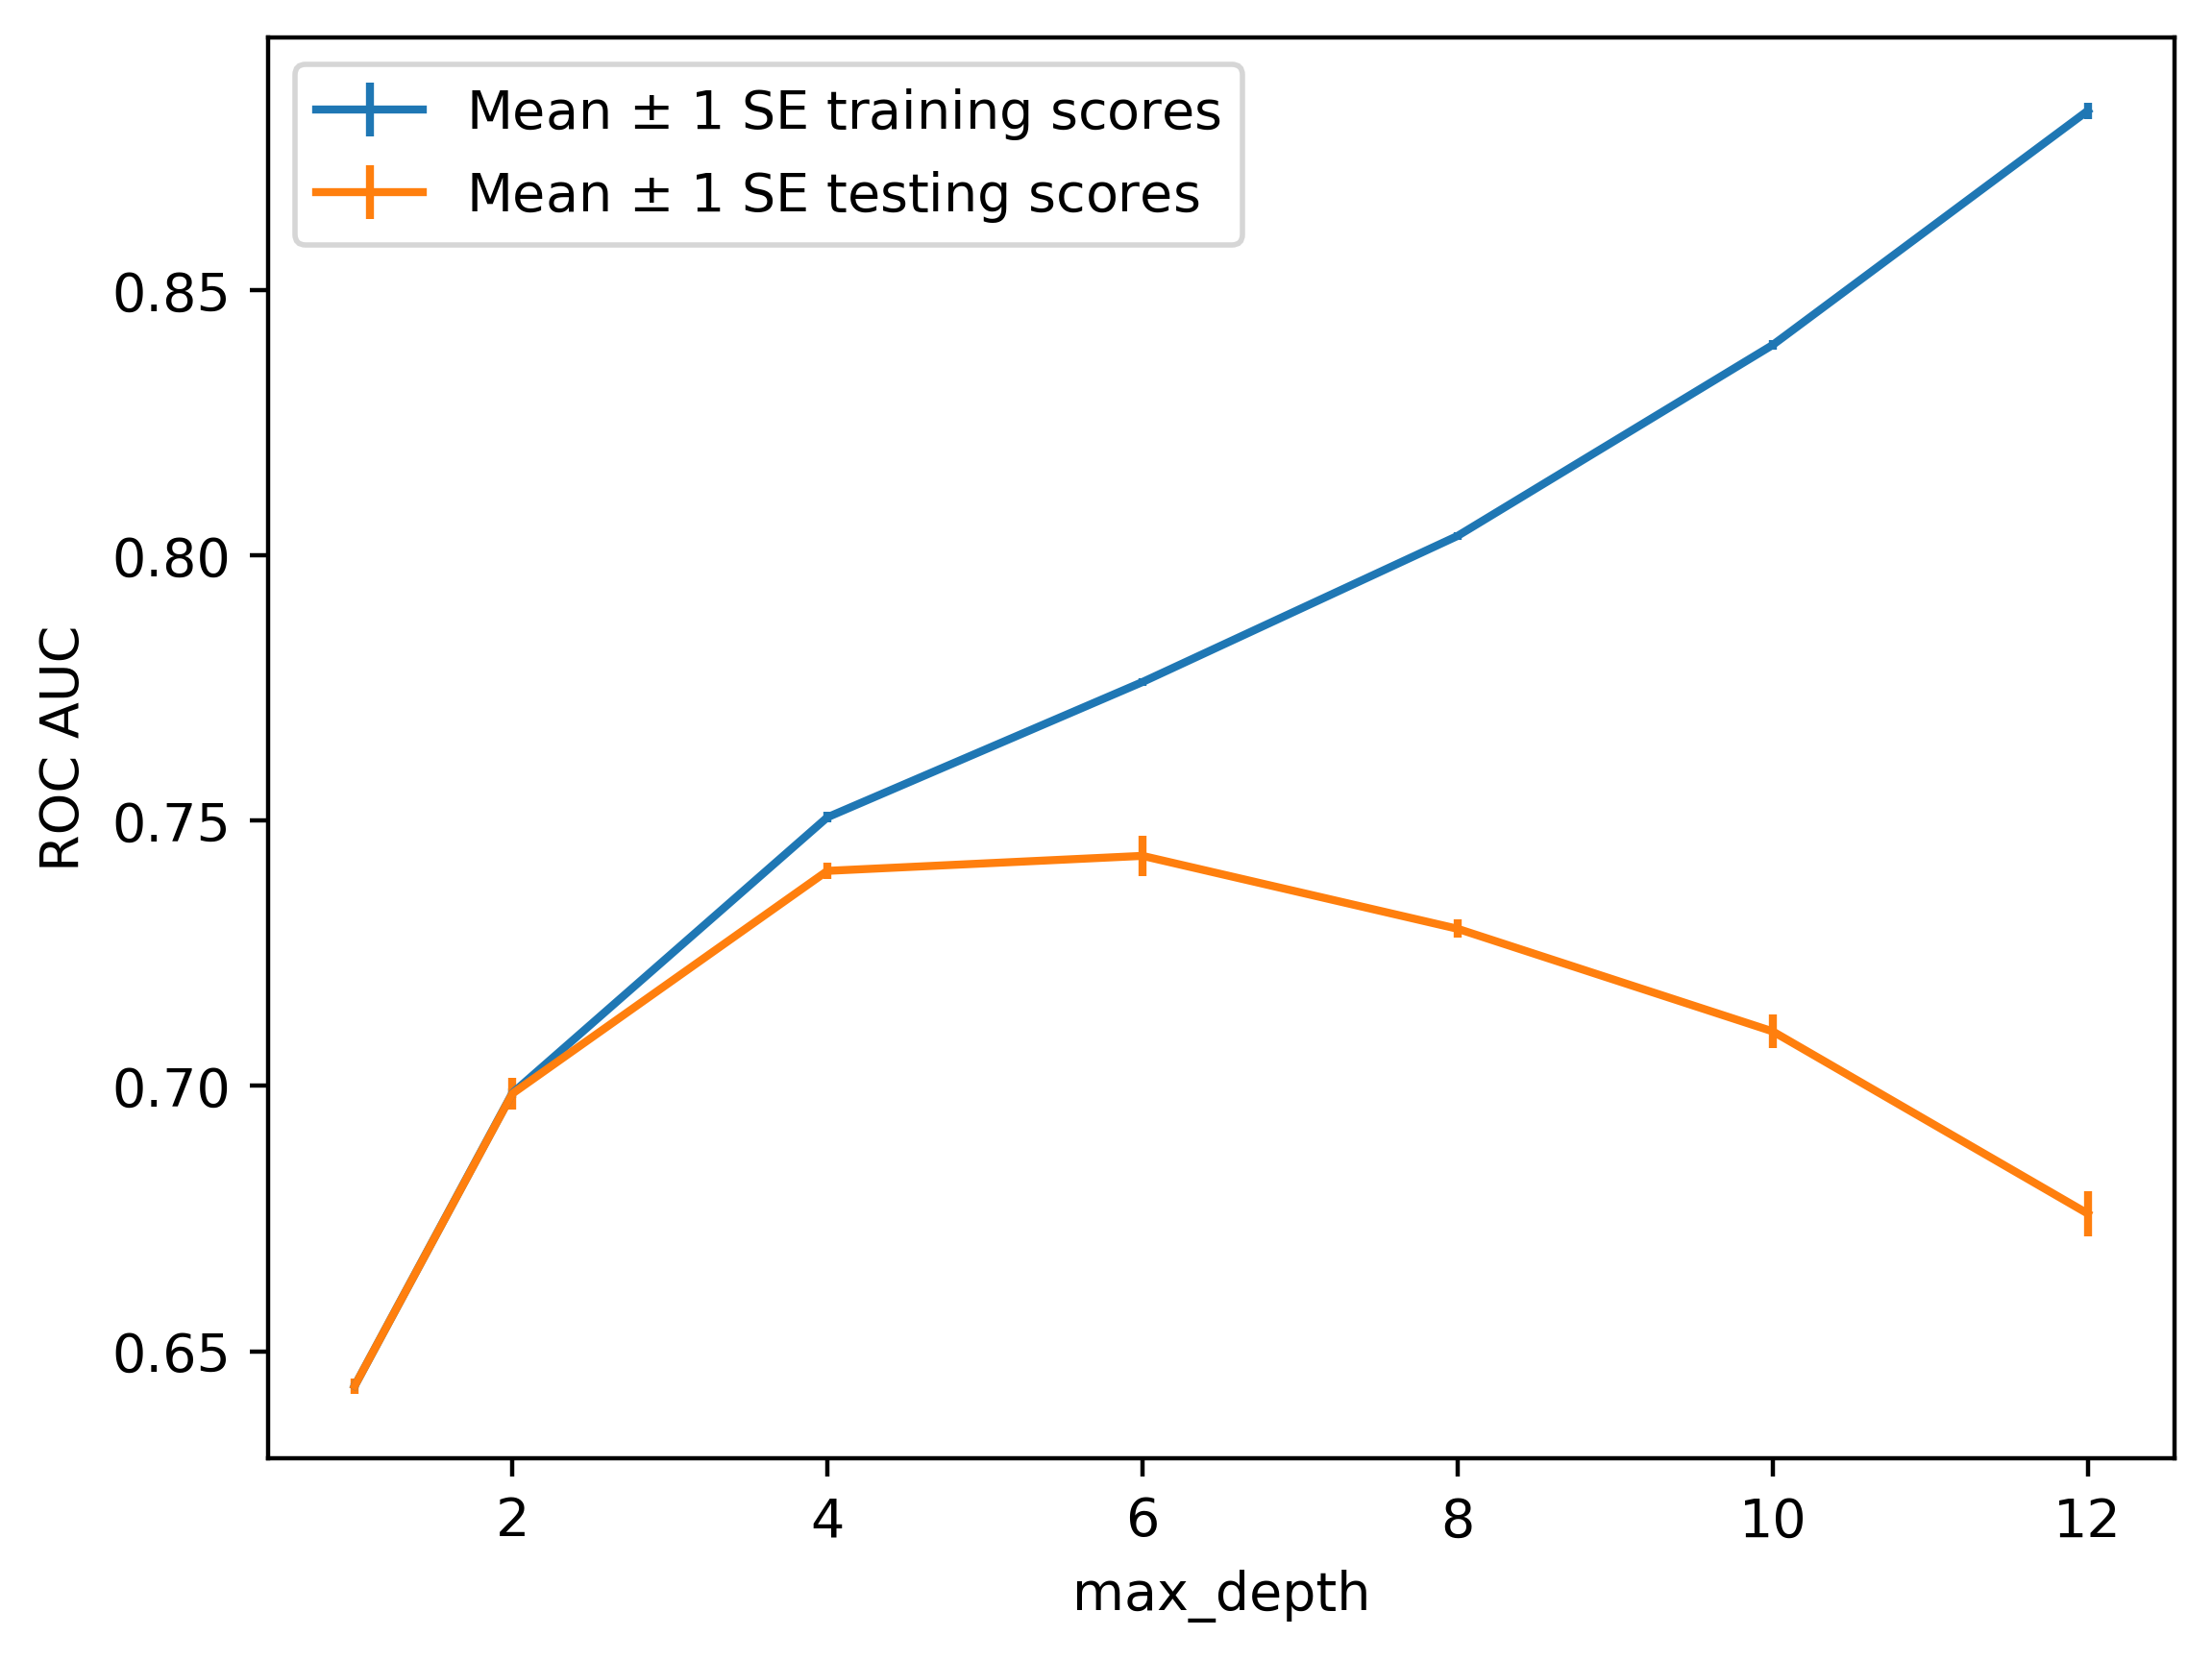

In [5]:
cv_results_df = pd.DataFrame(cv.cv_results_)
#View the names of the remaining columns in the results DataFrame
cv_results_df.columns
ax = plt.axes()
ax.errorbar(cv_results_df['param_max_depth'],
cv_results_df['mean_train_score'],
yerr=cv_results_df['std_train_score']/np.sqrt(4),
label='Mean $\pm$ 1 SE training scores')
ax.errorbar(cv_results_df['param_max_depth'],
cv_results_df['mean_test_score'],
yerr=cv_results_df['std_test_score']/np.sqrt(4),
label='Mean $\pm$ 1 SE testing scores')
ax.legend()
plt.xlabel('max_depth')
plt.ylabel('ROC AUC')

**Nhận xét:** Training ROC AUC tăng đều khi max_depth tăng → mô hình càng phức tạp thì càng khớp dữ liệu huấn luyện tốt hơn. Testing ROC AUC đạt đỉnh ở khoảng max_depth = 4, sau đó giảm dần → dấu hiệu rõ ràng của overfitting khi mô hình quá phức tạp. Khoảng cách giữa hai đường càng lớn ở độ sâu cao → mô hình học quá kỹ dữ liệu huấn luyện, mất khả năng tổng quát hóa. 

**Kết luận:** max_depth = 4 là điểm cân bằng tốt giữa độ chính xác và khả năng tổng quát. Mô hình nên được giới hạn độ sâu để tránh overfitting và đảm bảo hiệu suất ổn định trên dữ liệu thực tế.